In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from matplotlib.ticker import FixedLocator

files = {
    'Native': '../../outputs/native3/summary_final.csv',
    'SME': '../../outputs/sme3/summary_final.csv', 
    'SME+SEV': '../../outputs/sev3/summary_final.csv'
}

matrix_path = '../../matrices/itertest'

def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(row['N'])}.bin")
    return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None

def get_n(f):
    m = re.search(r'N(\d+)', f)
    return int(m.group(1)) if m else 0

def get_rand(f):
    m = re.search(r'(\d)-(\d)', f)
    return float(f"{m.group(1)}.{m.group(2)}") if m else 0.0

def load_and_process(label, path):
    if not os.path.exists(path): 
        print(f"Warning: File for {label} not found at {path}. Skipping.")
        return None
    df = pd.read_csv(path)
    df['Mode'] = label
    df['N'] = df['Matrix'].apply(get_n)
    df['Randomness'] = df['Matrix'].apply(get_rand)
    df['MB'] = df.apply(get_mb, axis=1).round().astype('Int64')
    return df

df_list = [load_and_process(l, p) for l, p in files.items()]
df_raw = pd.concat([d for d in df_list if d is not None])

group_cols = ['Mode', 'Cores', 'MB', 'Randomness', 'NUMA']
metrics = ['Gflops', 'Runtime', 'Insn', 'Cycl', 'RefCycl', 'Cache_Miss', 'Stalls', 'PgFault']

df = df_raw.groupby(group_cols)[metrics].median().reset_index()

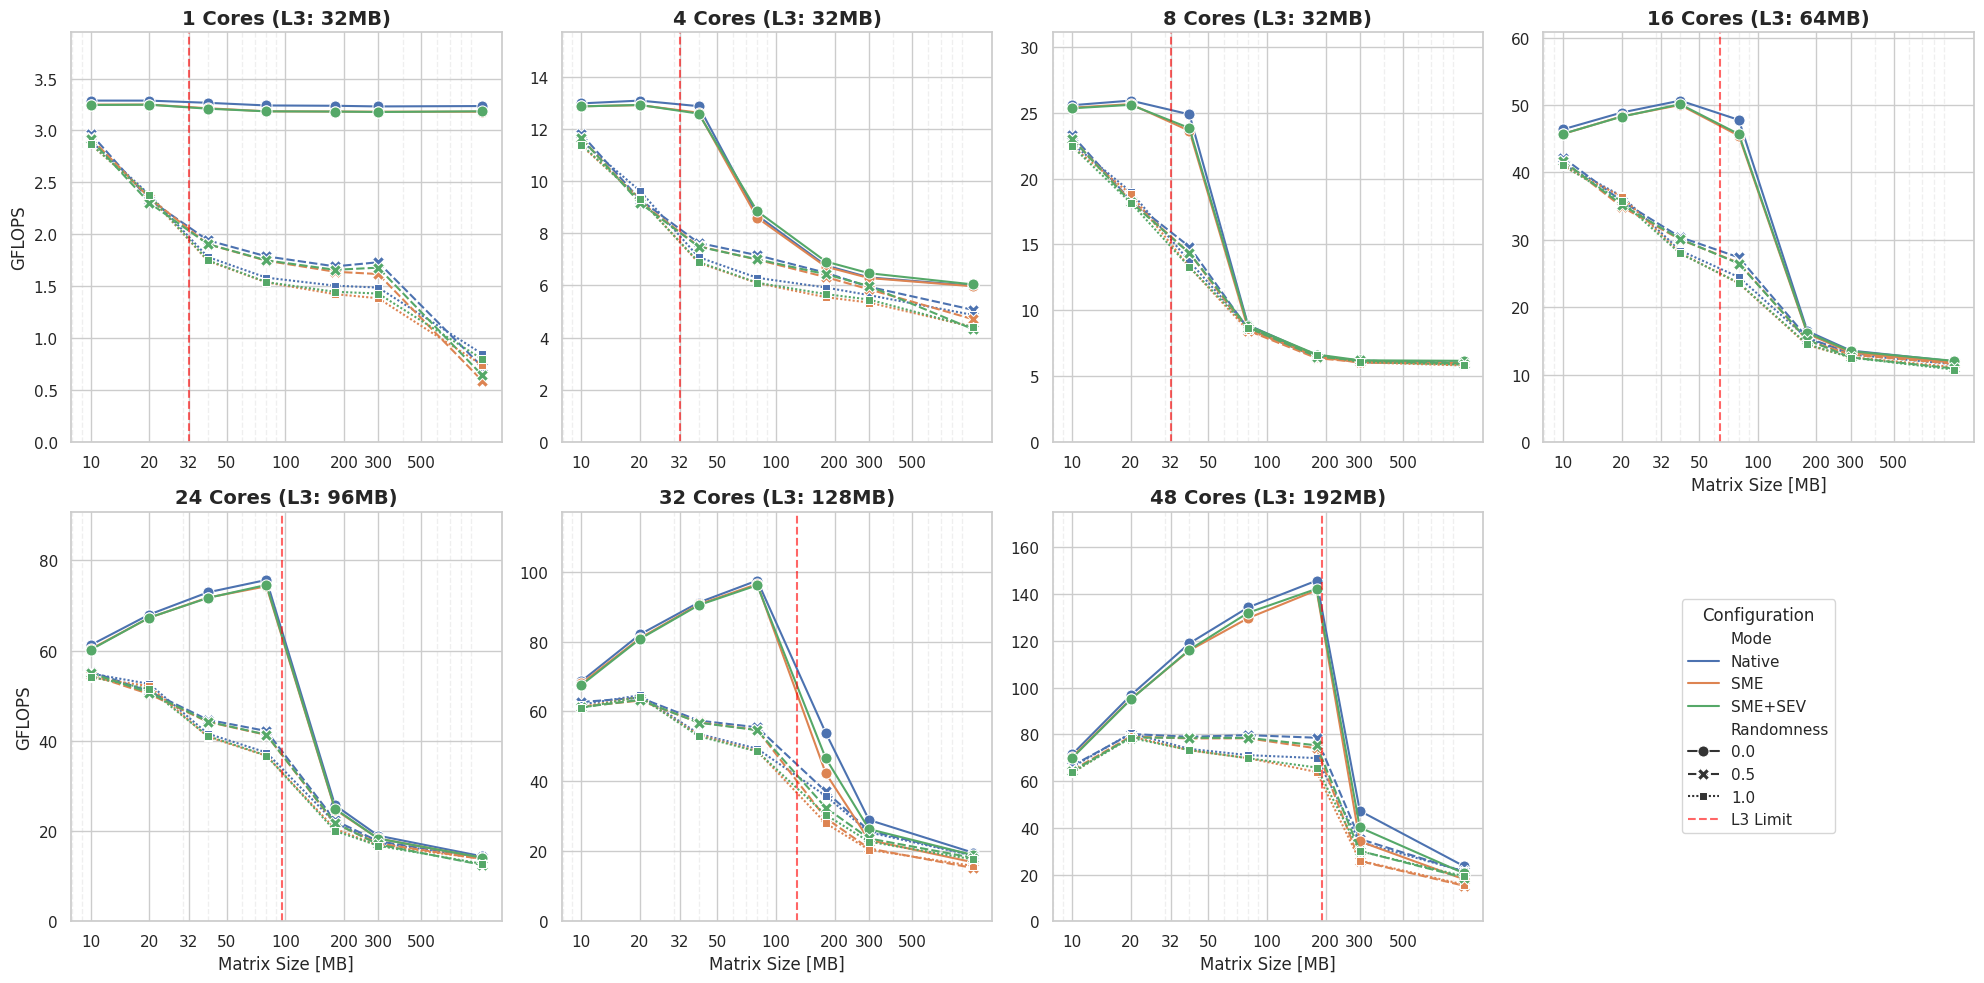

In [15]:
sns.set_theme(style="whitegrid", font_scale=1.0)
unique_cores = sorted(df['Cores'].unique())

n_cols = 4
n_rows = (len(unique_cores) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

x_ticks = [10, 20, 32, 50, 100, 200, 300, 500]

for idx, core in enumerate(unique_cores):
    ax = axes[idx]
    subset_core = df[df['Cores'] == core].sort_values('MB')
    
    l3_capacity = np.ceil(core / 8) * 32
    ax.set_xscale('log')
    
    sns.lineplot(data=subset_core, x='MB', y='Gflops', 
                 hue='Mode', style='Randomness', 
                 markers=True, markersize=8, ax=ax, 
                 errorbar=None, legend=(idx == 0))
    
    ax.axvline(x=l3_capacity, color='red', linestyle='--', alpha=0.6, label='L3 Limit')
    
    ax.set_xticks(x_ticks)
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    
    ax.set_title(f'{core} Cores (L3: {int(l3_capacity)}MB)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Matrix Size [MB]' if idx >= (len(unique_cores)-n_cols) else '')
    ax.set_ylabel('GFLOPS' if idx % n_cols == 0 else '')
    
    if not subset_core.empty:
        ax.set_ylim(0, subset_core['Gflops'].max() * 1.2)
        
    ax.grid(True, which="minor", ls="--", alpha=0.3)

for i in range(len(unique_cores), len(axes)):
    axes[i].axis('off')

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
if len(axes) > len(unique_cores):
    axes[-1].legend(by_label.values(), by_label.keys(), loc='center', title='Configuration')
    axes[0].get_legend().remove()

plt.tight_layout()
plt.show()

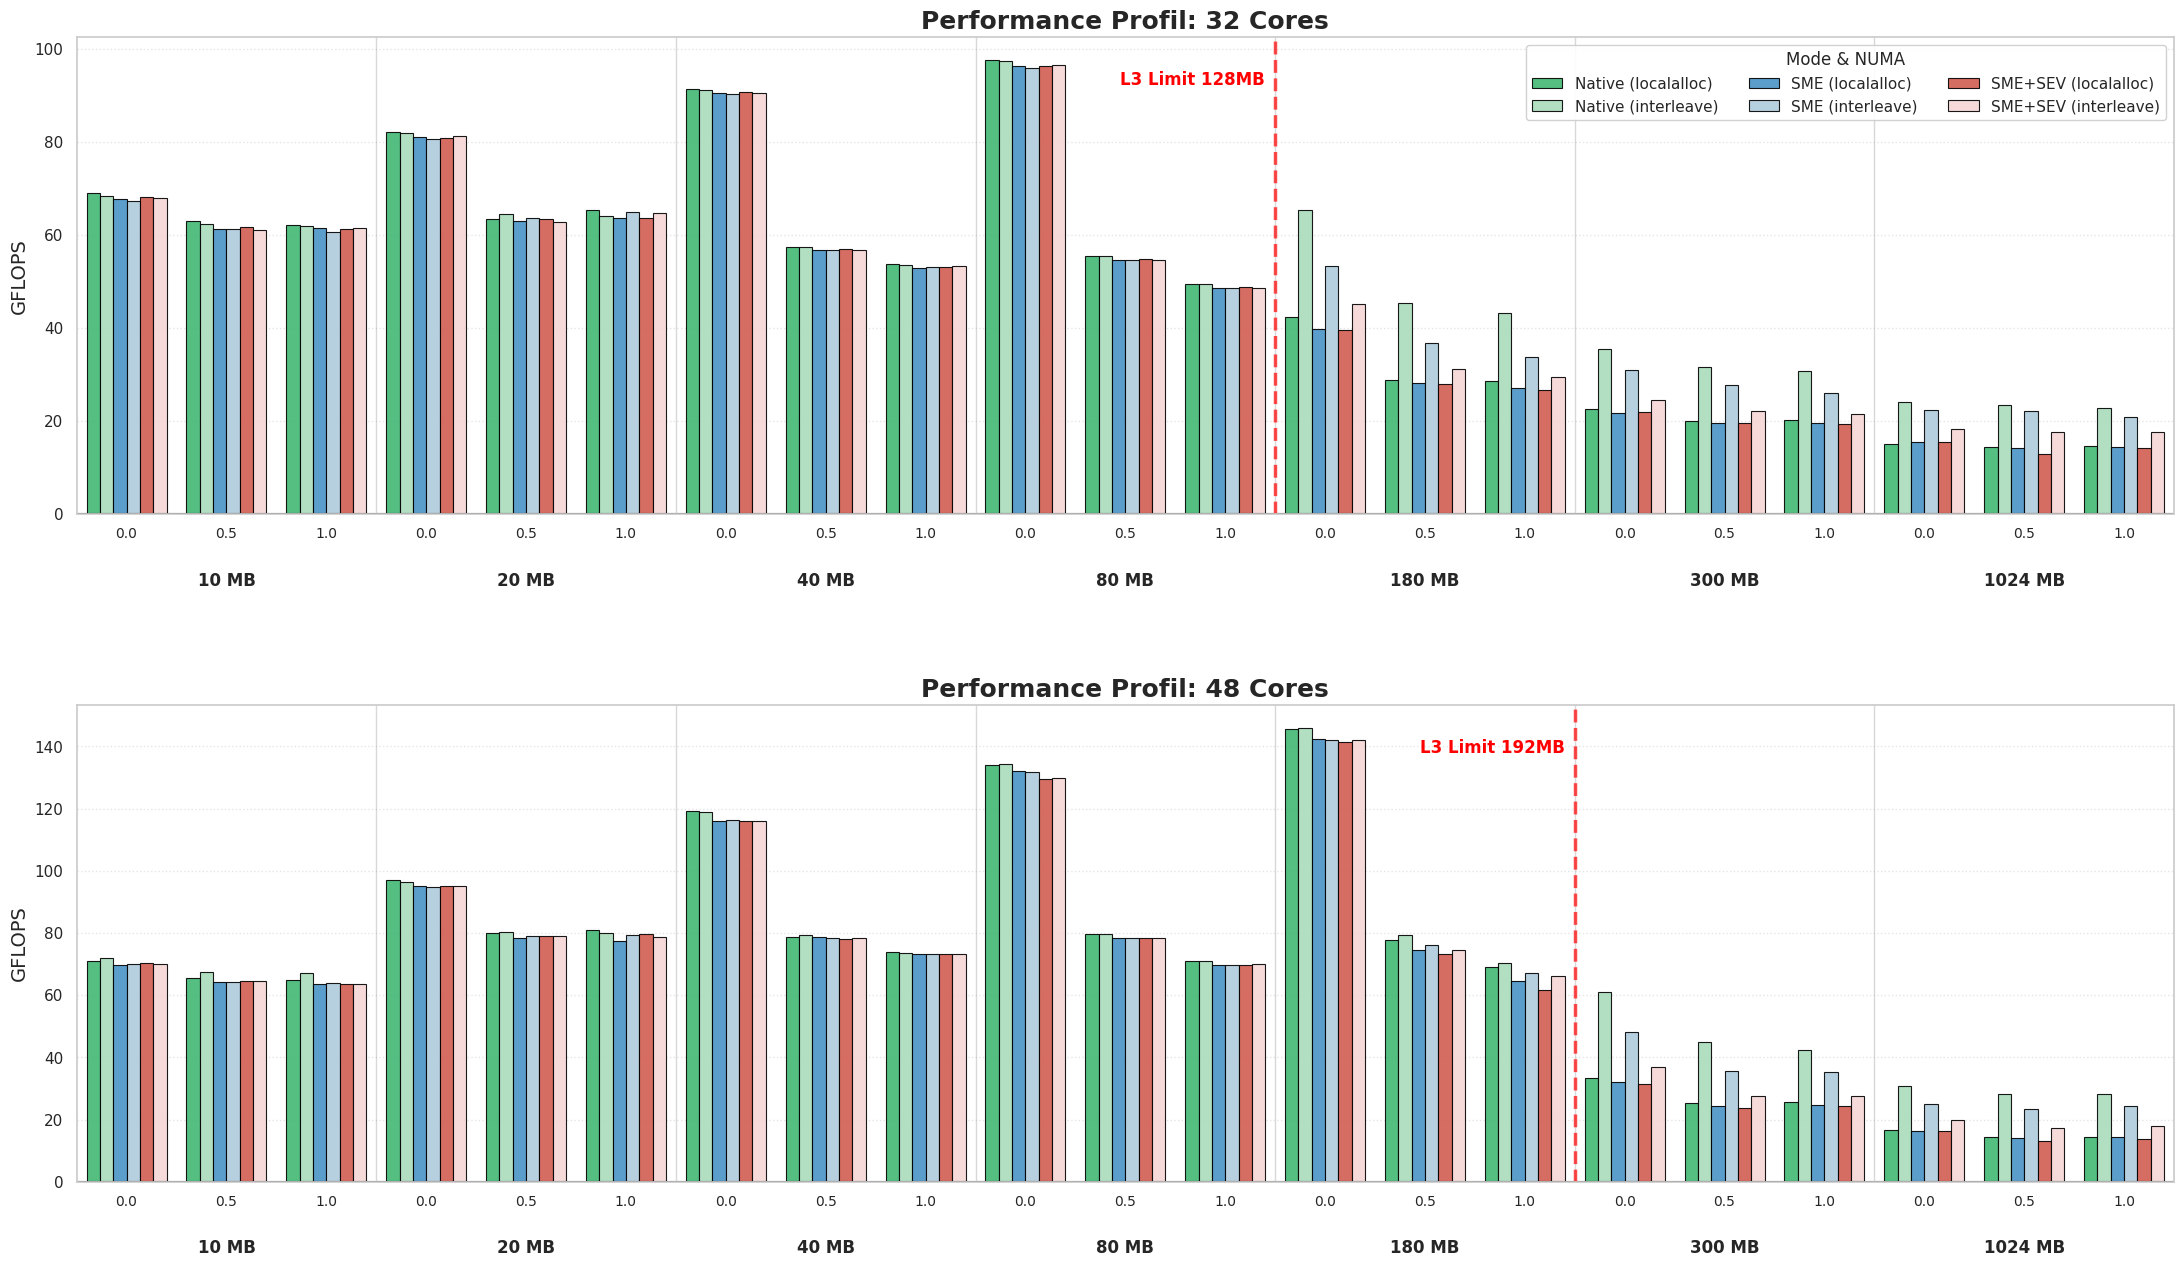

In [16]:
df_plot = df[df['Cores'].isin([32, 48])].copy()
df_plot['Config'] = df_plot.apply(lambda x: f"{x['Mode']} ({x['NUMA']})", axis=1)
df_plot = df_plot.sort_values(['MB', 'Randomness'])

unique_configs = [
    "Native (localalloc)", "Native (interleave)",
    "SME (localalloc)", "SME (interleave)",
    "SME+SEV (localalloc)", "SME+SEV (interleave)"
]

colors = [
    '#2ecc71', '#a2e4b8', 
    '#3498db', '#a9cce3', 
    '#e74c3c', '#fad1d1'  
]
color_palette = dict(zip(unique_configs, colors))

# 3. Plotting
fig, axes = plt.subplots(2, 1, figsize=(22, 14))
unique_mbs = sorted(df_plot['MB'].unique())
unique_rands = sorted(df_plot['Randomness'].unique())
num_rands = len(unique_rands)

for i, core in enumerate([32, 48]):
    ax = axes[i]
    subset = df_plot[df_plot['Cores'] == core].copy()
    subset['group_idx'] = subset.groupby(['MB', 'Randomness']).ngroup()
    
    sns.barplot(
        data=subset, x='group_idx', y='Gflops',
        hue='Config', hue_order=unique_configs,
        palette=color_palette, ax=ax, 
        edgecolor="black", linewidth=0.8, alpha=0.9
    )

    ax.axhline(0, color='black', linewidth=1.5)
    
    tick_pos = range(len(subset['group_idx'].unique()))
    ax.xaxis.set_major_locator(FixedLocator(tick_pos))
    ax.set_xticklabels([str(r) for m in unique_mbs for r in unique_rands], fontsize=10)
    
    current_ymin, current_ymax = ax.get_ylim()
    label_y_pos = current_ymin - (current_ymax * 0.12)

    for idx, mb in enumerate(unique_mbs):
        center_pos = (idx * num_rands) + (num_rands - 1) / 2
        ax.text(center_pos, label_y_pos, f"{mb} MB", 
                ha='center', va='top', fontsize=12, fontweight='bold')
        
        if idx < len(unique_mbs) - 1:
            ax.axvline(x=(idx * num_rands) + num_rands - 0.5, color='gray', linewidth=1, alpha=0.3)

    limit = 128 if core == 32 else 192
    line_idx = -0.5
    for idx, mb in enumerate(unique_mbs):
        if mb < limit: line_idx = (idx * num_rands) + num_rands - 0.5
    
    ax.axvline(x=line_idx, color='red', linestyle='--', linewidth=2.5, alpha=0.7)
    ax.text(line_idx - 0.1, current_ymax * 0.9, f'L3 Limit {limit}MB', 
            color='red', fontweight='bold', ha='right', fontsize=12)

    # Styling
    ax.set_title(f'Performance Profil: {core} Cores', fontsize=18, fontweight='bold')
    ax.set_ylabel('GFLOPS', fontsize=14)
    ax.set_xlabel('')
    ax.grid(True, axis='y', ls=':', alpha=0.5)
    
    if i == 0:
        ax.legend(title="Mode & NUMA", loc='upper right', ncol=3, framealpha=0.9)
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.subplots_adjust(bottom=0.15, hspace=0.4)
plt.show()

In [4]:
stats_df = df_raw.groupby(['Mode', 'Cores', 'MB', 'Randomness', 'NUMA']).agg(
    Gflops_med=('Gflops', 'median'),
    Jitter_pct=('Gflops', lambda x: (x.std() / x.mean() * 100) if x.mean() > 0 else 0)
).reset_index()

gflops_pivot = stats_df.pivot_table(
    index=['Cores', 'MB', 'Randomness', 'NUMA'], 
    columns='Mode', 
    values='Gflops_med'
).reset_index()

jitter_pivot = stats_df.pivot_table(
    index=['Cores', 'MB', 'Randomness', 'NUMA'], 
    columns='Mode', 
    values='Jitter_pct'
).add_suffix('_Jitter%').reset_index()

final_df = pd.merge(gflops_pivot, jitter_pivot, on=['Cores', 'MB', 'Randomness', 'NUMA'])

final_df['SME_vs_Nat_%'] = (final_df['SME'] / final_df['Native'] - 1) * 100
final_df['SEV_vs_Nat_%'] = (final_df['SEV'] / final_df['Native'] - 1) * 100
final_df['SEV_vs_SME_%'] = (final_df['SEV'] / final_df['SME'] - 1) * 100

def apply_distinct_colors(val):
    if pd.isna(val): return ''
    if val <= -0.5:
        return 'background-color: #ffcccc; color: #cc0000; font-weight: bold' # Rot
    elif val >= 0.5:
        return 'background-color: #ccffcc; color: #006600; font-weight: bold' # Grün
    return 'background-color: #f2f2f2; color: #666666' # Grau (Neutral)

diff_cols = ['SME_vs_Nat_%', 'SEV_vs_Nat_%', 'SEV_vs_SME_%']
jitter_cols = ['Native_Jitter%', 'SME_Jitter%', 'SEV_Jitter%']
display_cols = ['Cores', 'MB', 'Randomness', 'NUMA', 'Native', 'SME', 'SEV'] + jitter_cols + diff_cols

styled_final = final_df[display_cols].sort_values(['NUMA', 'Cores', 'MB']).style\
    .format({
        'Native': '{:.3f}', 'SME': '{:.3f}', 'SEV': '{:.3f}',
        'Native_Jitter%': '{:.1f}%', 'SME_Jitter%': '{:.1f}%', 'SEV_Jitter%': '{:.1f}%',
        'SME_vs_Nat_%': '{:+.2f}%', 'SEV_vs_Nat_%': '{:+.2f}%', 'SEV_vs_SME_%': '{:+.2f}%'
    })\
    .map(apply_distinct_colors, subset=diff_cols)\
    .set_caption("Gflops, Jitter & Overheads")

display(styled_final)

Mode,Cores,MB,Randomness,NUMA,Native,SME,SEV,Native_Jitter%,SME_Jitter%,SEV_Jitter%,SME_vs_Nat_%,SEV_vs_Nat_%,SEV_vs_SME_%
105,32,10,0.000000,interleave,68.390,67.334,67.838,1.3%,0.9%,1.1%,-1.54%,-0.81%,+0.75%
107,32,10,0.500000,interleave,62.433,61.160,61.009,1.7%,2.5%,1.5%,-2.04%,-2.28%,-0.25%
109,32,10,1.000000,interleave,61.847,60.622,61.487,0.5%,0.5%,1.6%,-1.98%,-0.58%,+1.43%
111,32,20,0.000000,interleave,81.933,80.544,81.151,0.3%,0.9%,0.7%,-1.69%,-0.95%,+0.75%
113,32,20,0.500000,interleave,64.413,63.706,62.837,1.5%,2.5%,2.1%,-1.10%,-2.45%,-1.36%
115,32,20,1.000000,interleave,64.069,64.823,64.801,3.5%,3.0%,3.2%,+1.18%,+1.14%,-0.03%
117,32,40,0.000000,interleave,91.064,90.313,90.490,2.2%,2.0%,0.2%,-0.83%,-0.63%,+0.20%
119,32,40,0.500000,interleave,57.394,56.817,56.769,0.4%,0.4%,0.6%,-1.01%,-1.09%,-0.08%
121,32,40,1.000000,interleave,53.491,53.046,53.408,0.5%,0.8%,0.6%,-0.83%,-0.15%,+0.68%
123,32,80,0.000000,interleave,97.297,95.898,96.503,1.3%,1.5%,0.2%,-1.44%,-0.82%,+0.63%
